## Importing Data and Libraries

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from scipy.stats import randint, uniform
from sklearn.metrics import (
    accuracy_score, auc, average_precision_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_style("whitegrid")
RANDOM_STATE = 42

df_identity = pd.read_csv("~/ML/Data/ieee-fraud-detection/train_identity.csv")
df_transaction = pd.read_csv("~/ML/Data/ieee-fraud-detection/train_transaction.csv")

df = df_transaction.merge(df_identity, how="left", on="TransactionID")
print(f"Train shape: {df.shape}")

/home/ldavi/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train shape: (590540, 434)


## Basic info about data

In [2]:
print(f"shape: {df.shape}")
print(f"fraud rate: {df['isFraud'].mean():.4f}")
df['isFraud'].value_counts()

shape: (590540, 434)
fraud rate: 0.0350


isFraud
0    569877
1     20663
Name: count, dtype: int64

## Visualizing imbalanced data

Fraud rate: 3.50%


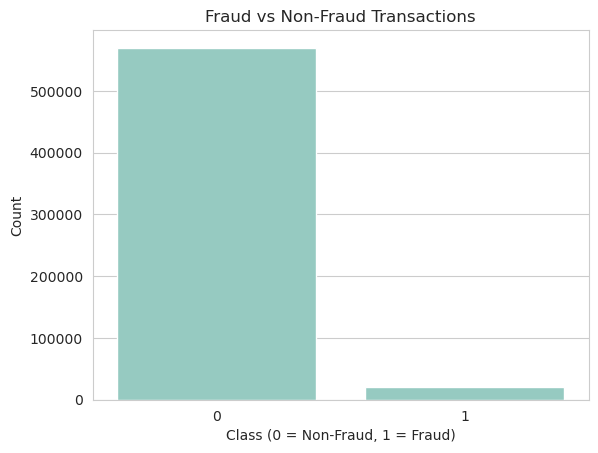

In [3]:
fraud_rate = df["isFraud"].mean()
print(f"Fraud rate: {fraud_rate:.2%}")

sns.countplot(data=df, x='isFraud')
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

## Missing Values Summary

In [4]:
miss = df.isna().mean().sort_values(ascending=False)
print(f"columns >80% missing: {(miss > 0.80).sum()}")
print(f"columns >50% missing: {(miss > 0.50).sum()}")
print("\nTop 20 missing columns:")
print(miss.head(20).round(3))

columns >80% missing: 74
columns >50% missing: 214

Top 20 missing columns:
id_24    0.992
id_25    0.991
id_07    0.991
id_08    0.991
id_21    0.991
id_26    0.991
id_27    0.991
id_23    0.991
id_22    0.991
dist2    0.936
D7       0.934
id_18    0.924
D13      0.895
D14      0.895
D12      0.890
id_04    0.888
id_03    0.888
D6       0.876
id_33    0.876
id_09    0.873
dtype: float64


## Visualizing Transaction Amount

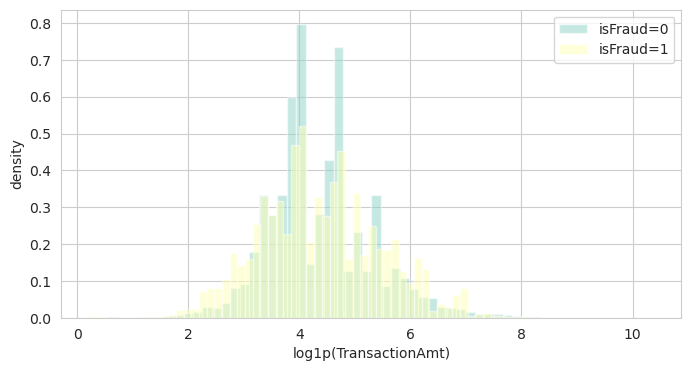

In [5]:
plt.figure(figsize=(8, 4))
for label in (0, 1):
    x = np.log1p(df.loc[df["isFraud"] == label, "TransactionAmt"])
    plt.hist(x, bins=60, alpha=0.5, label=f"isFraud={label}", density=True)
plt.xlabel("log1p(TransactionAmt)")
plt.ylabel("density")
plt.legend()
plt.show()

## Handling NaN Values

In [6]:
def clean(df, nan_col_thresh=0.7, row_nan_frac=0.5):
    """Drop columns where >nan_col_thresh fraction are NaN, then drop sparse rows."""
    cols_to_remove = df.columns[df.isna().mean() > nan_col_thresh].tolist()
    df_clean = df.drop(columns=cols_to_remove, errors="ignore")
    min_non_nan = int(df_clean.shape[1] * (1 - row_nan_frac))
    df_clean = df_clean.dropna(axis=0, thresh=min_non_nan)
    return df_clean, cols_to_remove

df_cleaned, dropped_cols = clean(df, nan_col_thresh=0.7, row_nan_frac=0.5)
print(f"after cleaning: {df_cleaned.shape} (dropped {len(dropped_cols)} cols)")

after cleaning: (590465, 226) (dropped 208 cols)


## Handling Missing Values

In [7]:
def impute_missing(df, num_strategy="median", cat_fill="missing"):
    """Numerical -> median; categorical -> 'missing' string."""
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(include=["object"]).columns
    if num_strategy == "median":
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    elif num_strategy == "mean":
        df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
    df[cat_cols] = df[cat_cols].fillna(cat_fill)
    return df

df = impute_missing(df_cleaned, num_strategy="median", cat_fill="missing")
print(f"NaNs remaining: {df.isna().sum().sum()}")

NaNs remaining: 0


## Categorical Values

In [8]:
cat_cols = df.select_dtypes("object").columns
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print(cardinality)

P_emaildomain    60
ProductCD         5
card4             5
card6             5
M4                4
M1                3
M2                3
M3                3
M5                3
M6                3
M7                3
M8                3
M9                3
dtype: int64


## Dropping High-Cardinality Columns

In [9]:
cols_to_drop = ["DeviceInfo", "id_30", "id_31", "id_33"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print(f"shape after manual drops: {df.shape}")

shape after manual drops: (590465, 226)


## Visualizing Fraud by Hour/Day/Month

/tmp/ipykernel_1476824/2480145208.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DT_day"]  = (df["TransactionDT"] // (3600 * 24)) % 7
/tmp/ipykernel_1476824/2480145208.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["DT_hour"] = (df["TransactionDT"] // 3600) % 24
/tmp/ipykernel_1476824/2480145208.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instea

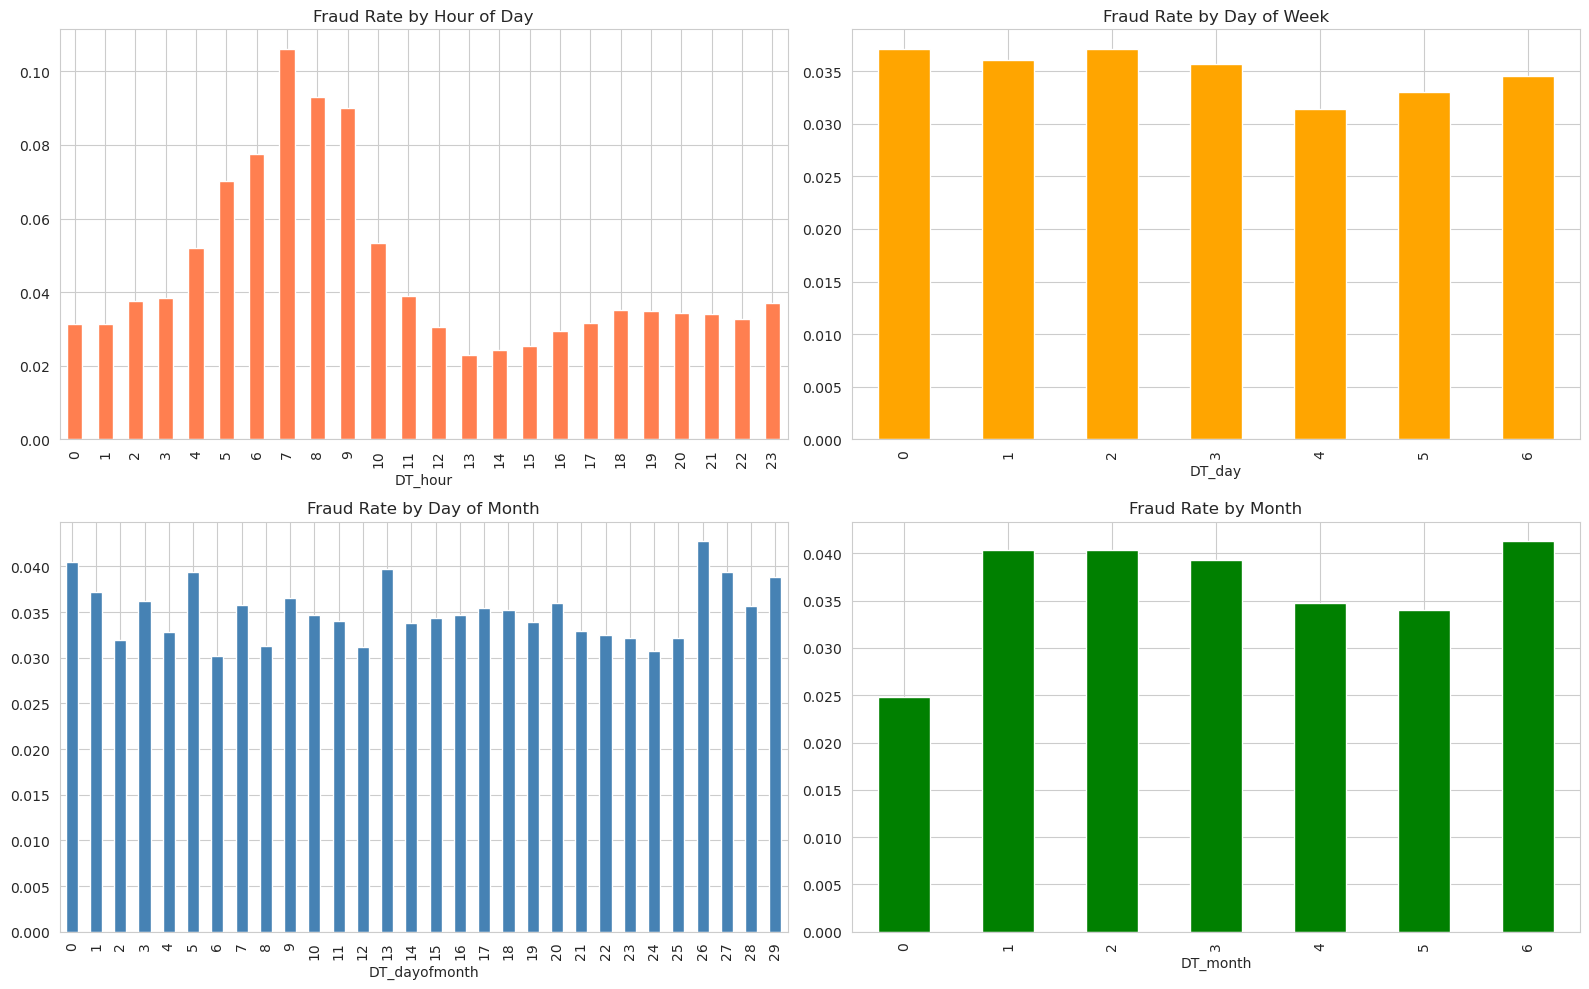

In [10]:
plt.close("all")
df["DT_day"]  = (df["TransactionDT"] // (3600 * 24)) % 7
df["DT_hour"] = (df["TransactionDT"] // 3600) % 24
df["DT_dayofmonth"] = (df["TransactionDT"] // (3600 * 24)) % 30
df["DT_month"] = (df["TransactionDT"] // (3600 * 24)) // 30


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df.groupby("DT_hour")["isFraud"].mean().plot(kind="bar", ax=axes[0,0], title="Fraud Rate by Hour of Day", color="coral")
df.groupby("DT_day")["isFraud"].mean().plot(kind="bar", ax=axes[0,1], title="Fraud Rate by Day of Week", color="orange")
df.groupby("DT_dayofmonth")["isFraud"].mean().plot(kind="bar", ax=axes[1,0], title="Fraud Rate by Day of Month", color="steelblue")
df.groupby("DT_month")["isFraud"].mean().plot(kind="bar", ax=axes[1,1], title="Fraud Rate by Month", color="green")

plt.tight_layout()
plt.savefig("fraud_by_time_features.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

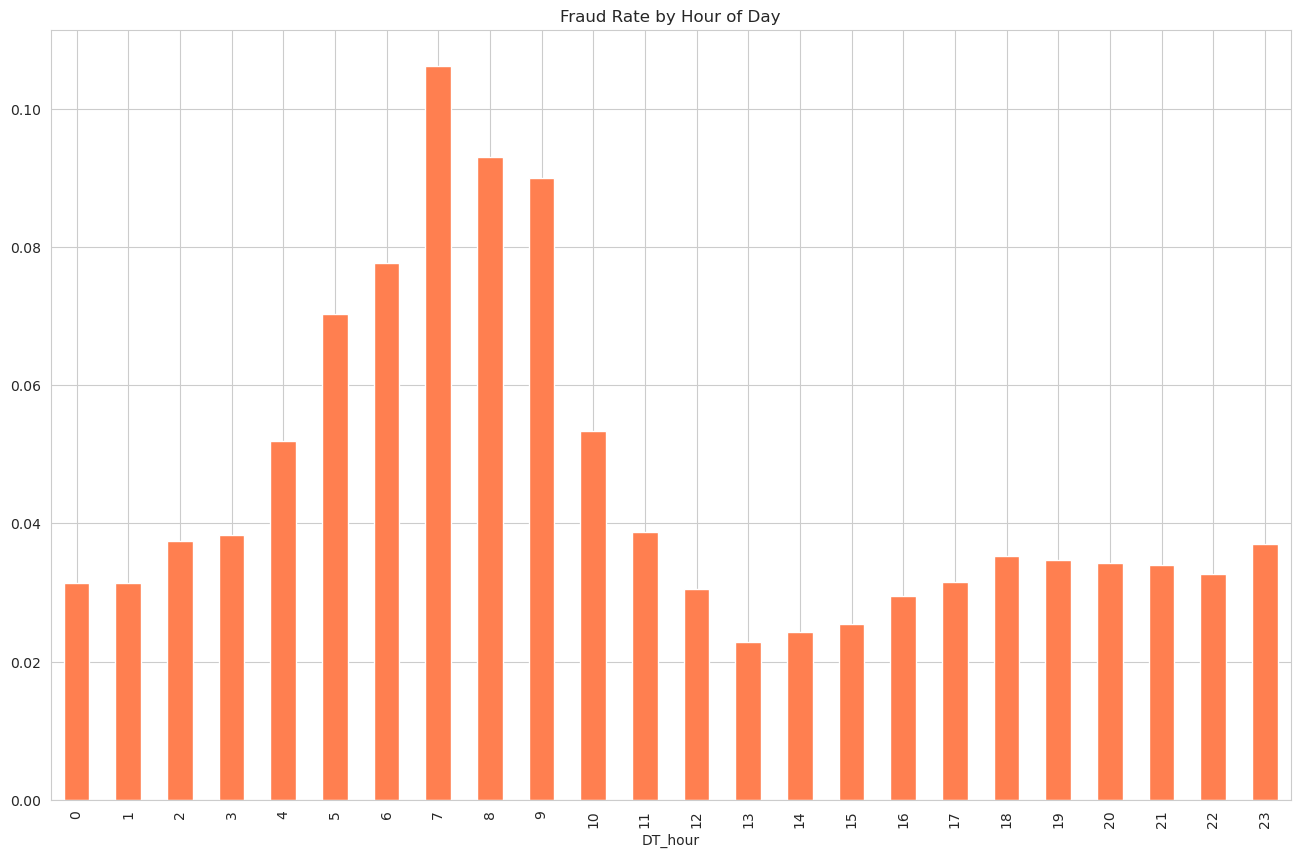

In [11]:
plt.figure(figsize=(16, 10))
df.groupby("DT_hour")["isFraud"].mean().plot(kind="bar",title="Fraud Rate by Hour of Day", color="coral")
plt.savefig("fraud_rate_by_hour_of_day.png", dpi=300, bbox_inches="tight")

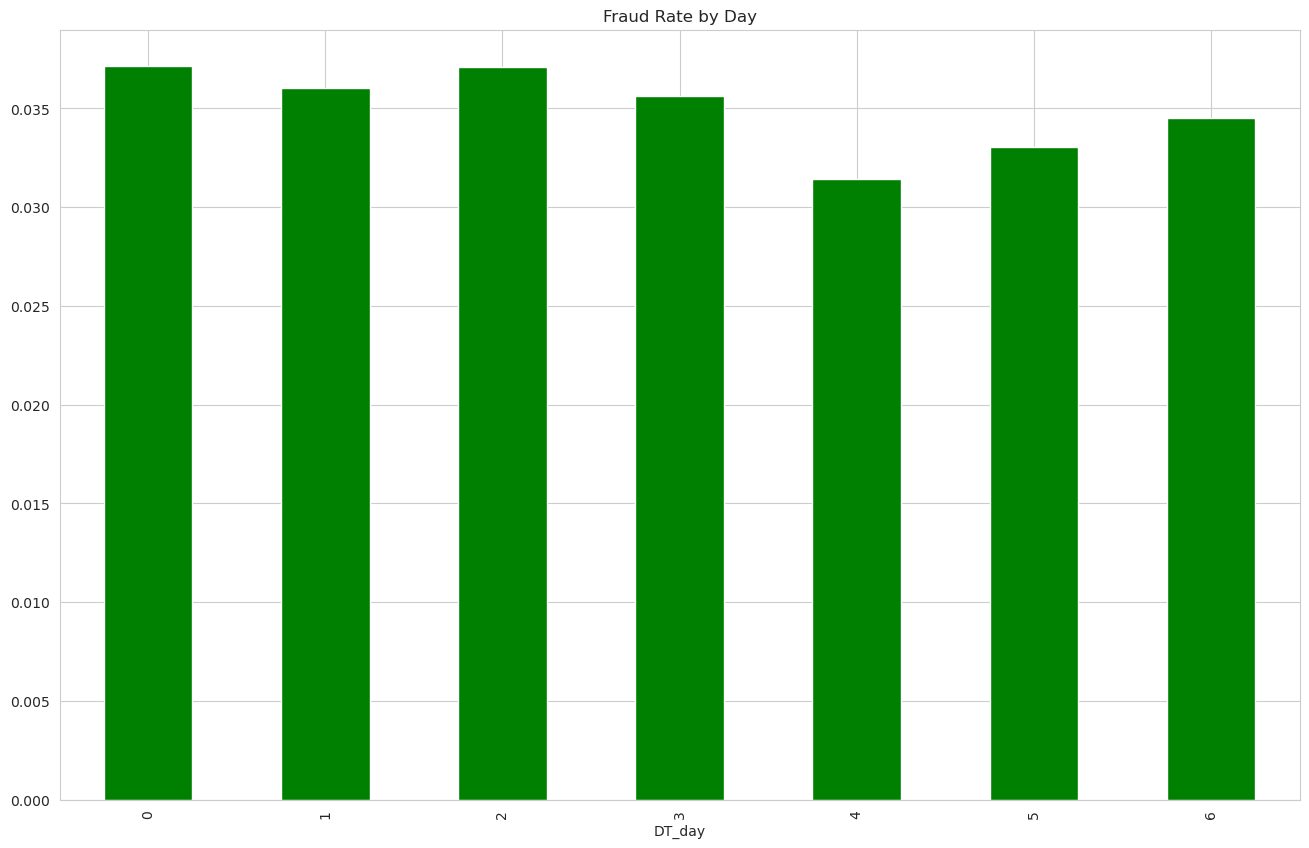

In [12]:
plt.figure(figsize=(16, 10))
df.groupby("DT_day")["isFraud"].mean().plot(kind="bar",title="Fraud Rate by Day", color="green")
plt.savefig("Fraud_Rate_by_Day_of_Week.png", dpi=300, bbox_inches="tight")

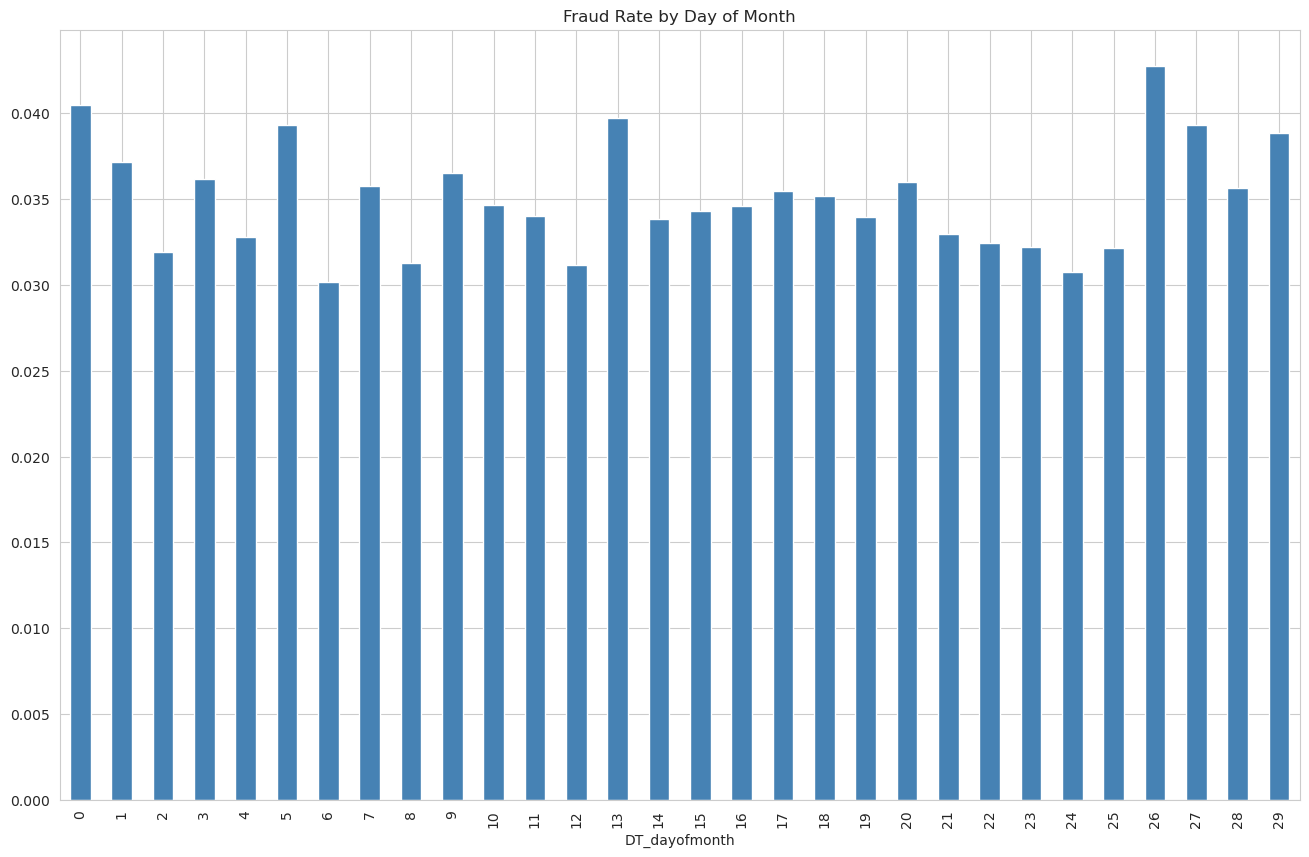

In [13]:
plt.figure(figsize=(16, 10))
df.groupby("DT_dayofmonth")["isFraud"].mean().plot(kind="bar", title="Fraud Rate by Day of Month", color="steelblue")
plt.savefig("Fraud_rate_by_day_of_month.png", dpi=300, bbox_inches="tight")

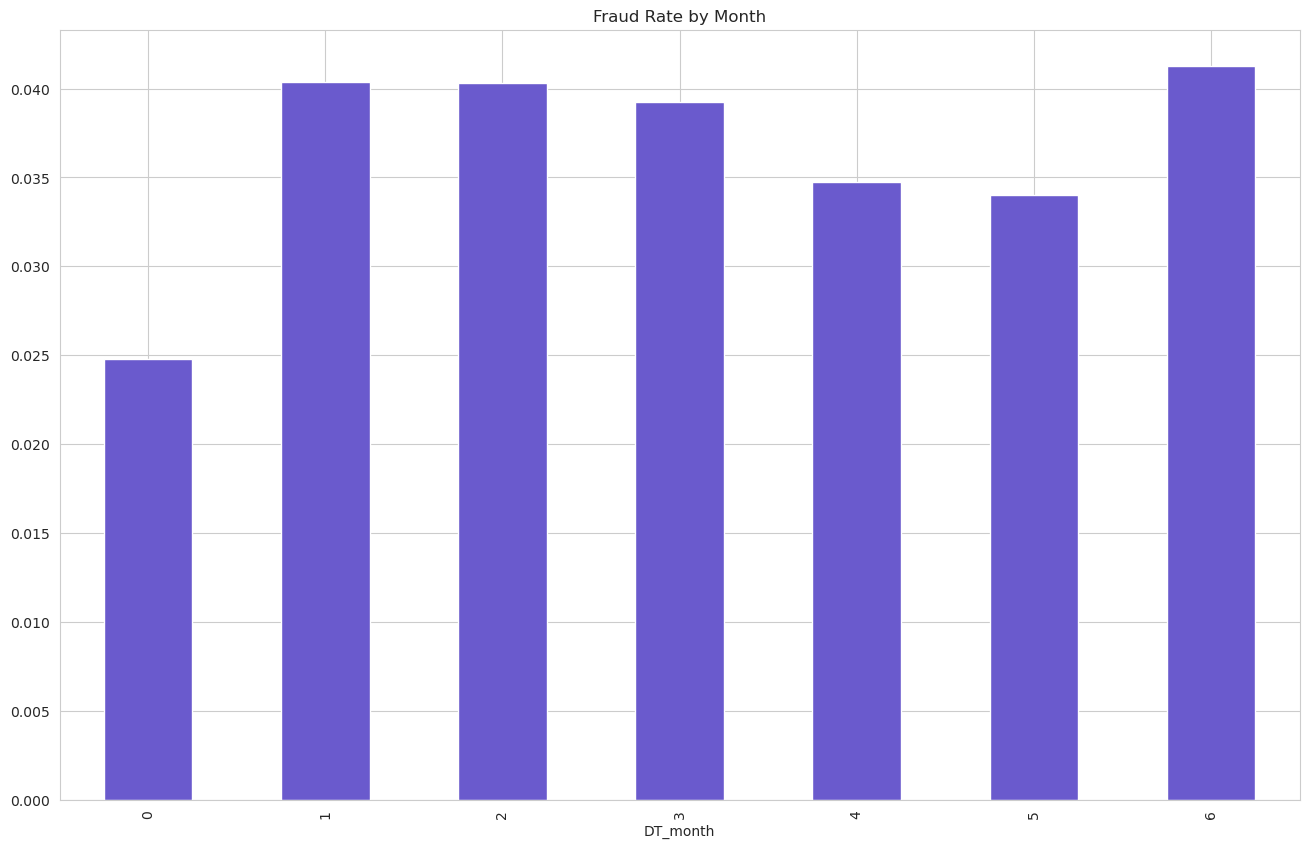

In [14]:
plt.figure(figsize=(16, 10))
df.groupby("DT_month")["isFraud"].mean().plot(kind="bar", title="Fraud Rate by Month", color="slateblue")
plt.savefig("Fraud_rate_by_month.png", dpi=300, bbox_inches="tight")

## Log Transform of TransactionAmt / Visualization

In [15]:
df["log_transactionAmt"] = np.log1p(df["TransactionAmt"])

/tmp/ipykernel_1476824/3450891445.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["log_transactionAmt"] = np.log1p(df["TransactionAmt"])


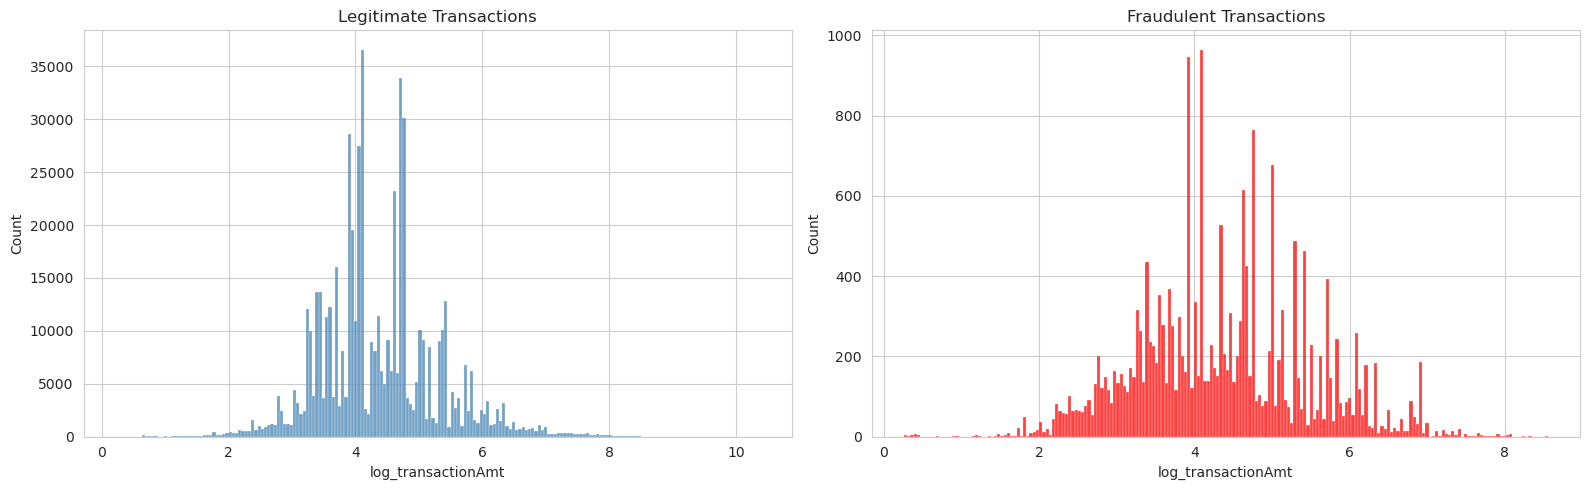

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(data=df[df["isFraud"] == 0], x="log_transactionAmt", bins=200,
             ax=axes[0], color="steelblue")
axes[0].set_title("Legitimate Transactions")
sns.histplot(data=df[df["isFraud"] == 1], x="log_transactionAmt", bins=200,
             ax=axes[1], color="red")
axes[1].set_title("Fraudulent Transactions")
plt.tight_layout()
plt.savefig("Log_Transaction_Amounts.png", dpi=300, bbox_inches="tight")
plt.show()

## Time Based Train/Valid Split

In [17]:
df.sort_values("TransactionDT", ascending=True, inplace=True)
n = int(df.shape[0] * 0.8)

x_train = df.iloc[:n, :].drop(columns=["isFraud"])
y_train = df.iloc[:n, :]["isFraud"]
x_valid = df.iloc[n:, :].drop(columns=["isFraud"])
y_valid = df.iloc[n:, :]["isFraud"]

print(f"x_train: {x_train.shape} | x_valid: {x_valid.shape}")
print(f"train fraud rate: {y_train.mean():.4f} | valid fraud rate: {y_valid.mean():.4f}")
print(f"train DT range: {x_train['TransactionDT'].min()} → {x_train['TransactionDT'].max()}")
print(f"valid DT range: {x_valid['TransactionDT'].min()} → {x_valid['TransactionDT'].max()}")

x_train: (472372, 230) | x_valid: (118093, 230)
train fraud rate: 0.0351 | valid fraud rate: 0.0344
train DT range: 86400 → 12191615
valid DT range: 12191624 → 15811131


## WoE

In [18]:
def get_cat_cols(df):
    return df.select_dtypes(include=["object", "category"]).columns.tolist()

def fit_woe(X, y, cat_cols):
    target_name = y.name or "target"
    df_fit = pd.concat([X[cat_cols].astype(str), y.rename(target_name)], axis=1)
    eps = 1e-6
    woe_maps = {}
    iv_values = {}
    for col in cat_cols:
        grp = df_fit.groupby(col)[target_name].agg(["count", "sum"])
        grp.columns = ["n_obs", "n_pos"]
        grp["n_neg"] = grp["n_obs"] - grp["n_pos"]
        prop_pos = (grp["n_pos"] + eps) / (grp["n_pos"].sum() + eps)
        prop_neg = (grp["n_neg"] + eps) / (grp["n_neg"].sum() + eps)
        woe = np.log(prop_pos / prop_neg)
        woe_maps[col] = woe.to_dict()
        iv_values[col] = float(((prop_pos - prop_neg) * woe).sum())
    return woe_maps, iv_values

def transform_woe(X, woe_maps):
    X_t = X.copy()
    for col, mapping in woe_maps.items():
        if col in X_t.columns:
            X_t[col] = X_t[col].astype(str).map(mapping).fillna(0).astype(float)
    return X_t

woe_maps, iv_values = fit_woe(x_train, y_train, cat_cols)

iv_df = pd.Series(iv_values).sort_values(ascending=False).to_frame("IV")
iv_df["strength"] = pd.cut(
    iv_df["IV"],
    bins=[-np.inf, 0.02, 0.10, 0.30, 0.50, np.inf],
    labels=["useless", "weak", "medium", "strong", "suspicious"],
)
print(iv_df)


x_train_enc = transform_woe(x_train, woe_maps)
x_valid_enc = transform_woe(x_valid, woe_maps)

print(f"x_train_enc: {x_train_enc.shape} | x_valid_enc: {x_valid_enc.shape}")

                     IV    strength
ProductCD      0.529372  suspicious
M4             0.441322      strong
M6             0.377805      strong
card6          0.264418      medium
M3             0.234104      medium
P_emaildomain  0.232728      medium
M2             0.227776      medium
M1             0.208693      medium
M9             0.148984      medium
M8             0.139549      medium
M7             0.136031      medium
M5             0.018919     useless
card4          0.011199     useless
x_train_enc: (472372, 230) | x_valid_enc: (118093, 230)


## Correlation Filtering

after correlation filter: (472372, 111)


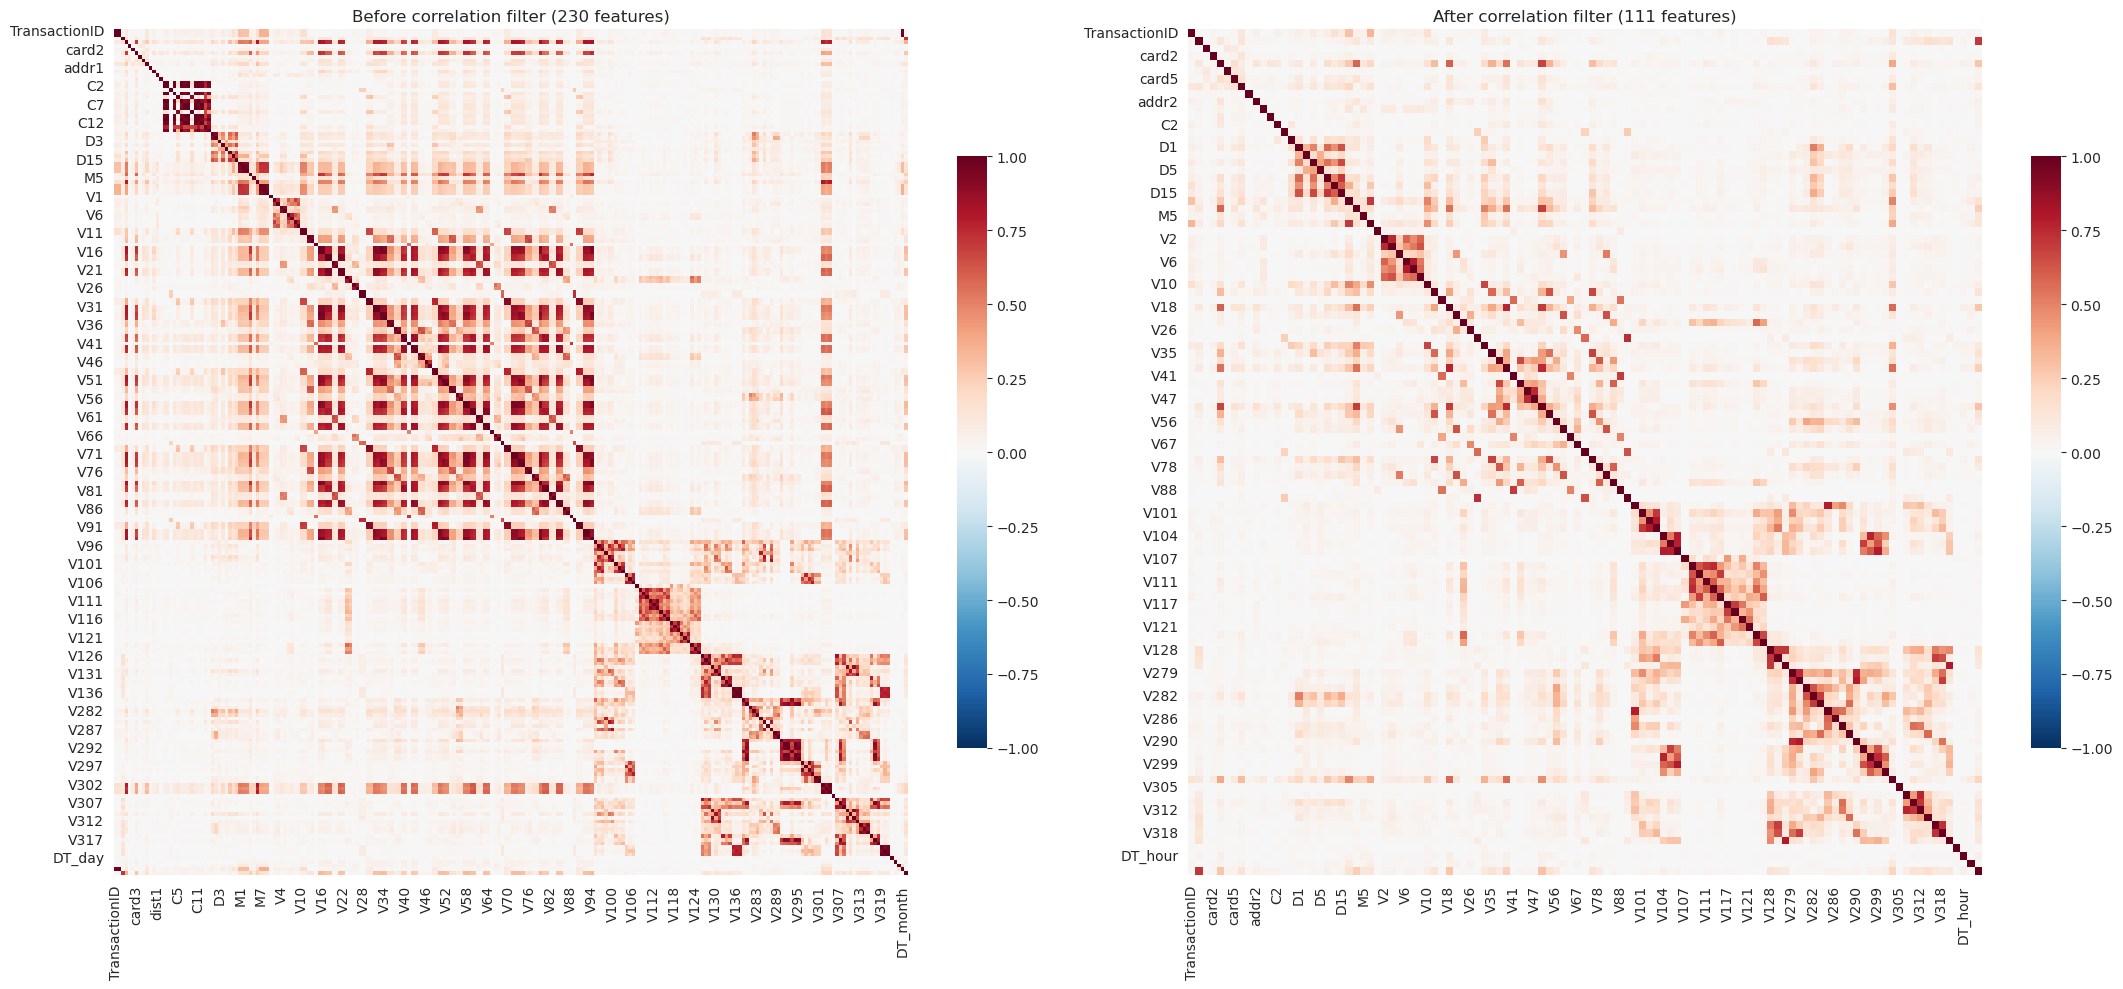

In [19]:
def correlation_filter(x_train, y_train, threshold):
    corr_matrix = np.abs(x_train.corr())

    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
                )

    features_drop = set()
    for feat1, feat2, val in high_corr_pairs:
        if abs(x_train[feat1].corr(y_train)) > abs(x_train[feat2].corr(y_train)):
            features_drop.add(feat2)
        else:
            features_drop.add(feat1)

    x_filtered = x_train.drop(columns=list(features_drop))
    return x_filtered


x_train_filt = correlation_filter(x_train_enc, y_train, threshold=0.8)
x_valid_filt = x_valid_enc[x_train_filt.columns]
print(f"after correlation filter: {x_train_filt.shape}")

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

sns.heatmap(x_train_enc.corr().abs(), cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=axes[0], cbar_kws={"shrink": 0.7})
axes[0].set_title(f"Before correlation filter ({x_train_enc.shape[1]} features)")

sns.heatmap(x_train_filt.corr().abs(), cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            ax=axes[1], cbar_kws={"shrink": 0.7})
axes[1].set_title(f"After correlation filter ({x_train_filt.shape[1]} features)")

plt.tight_layout()
plt.savefig("correlation_heatmap_before_after.png", dpi=200, bbox_inches="tight")
plt.show()

In [20]:
x_train_filt["M5"]

0        -0.276379
1         0.109869
2        -0.276379
3         0.109869
4         0.053757
            ...   
472386    0.053757
472387    0.053757
472388   -0.276379
472389    0.053757
472390    0.053757
Name: M5, Length: 472372, dtype: float64

## Training Baseline Model For SHAP

In [24]:
def get_xgb_model(y, **overrides):
    """XGBoost with sane defaults; scale_pos_weight handles imbalance natively."""
    scale = (y == 0).sum() / max((y == 1).sum(), 1)
    params = dict(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1.0,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=scale,
        min_child_weight=10,
        max_delta_step=1,
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    params.update(overrides)
    return xgb.XGBClassifier(**params)

x_train_for_model = x_train_filt.drop(columns=["TransactionID"], errors="ignore")
x_valid_for_model = x_valid_filt.drop(columns=["TransactionID"], errors="ignore")

baseline_model = get_xgb_model(y_train)
baseline_model.fit(x_train_for_model, y_train)
print("baseline trained")

baseline trained


In [25]:
explainer = shap.TreeExplainer(baseline_model)
shap_values = explainer.shap_values(x_train_for_model)

shap_importance = pd.DataFrame({
    'feature': x_train_for_model.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print(shap_importance.head(20))
print(f'\nFeatures with importance > 0.001: {(shap_importance["importance"] > 0.001).sum()}')
print(f'Features with importance < 0.001: {(shap_importance["importance"] < 0.001).sum()}')

                feature  importance
10                   C2    0.403583
38                  V29    0.403034
5                 card6    0.206618
0        TransactionAmt    0.197299
9         P_emaildomain    0.194186
21                   M4    0.183725
3                 card3    0.168638
13                   D1    0.134642
14                   D3    0.118597
19                  D15    0.118458
1                 card1    0.117857
95                 V304    0.113742
4                 card5    0.109588
2                 card2    0.107199
20                   M3    0.102726
15                   D4    0.095695
47                  V53    0.083141
107  log_transactionAmt    0.081872
61                 V102    0.078796
105             DT_hour    0.068480

Features with importance > 0.001: 78
Features with importance < 0.001: 30


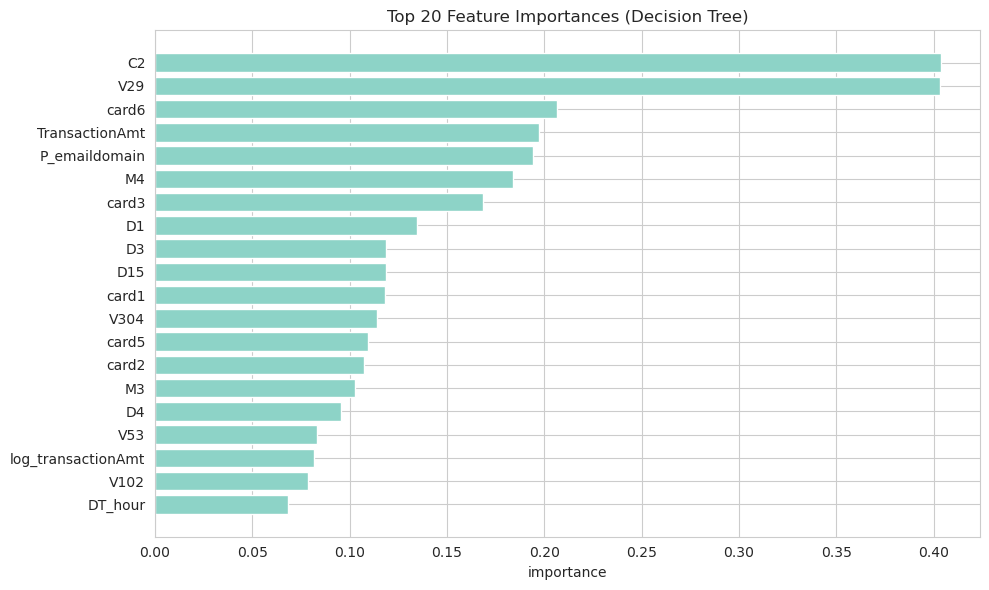

In [26]:
top_features = shap_importance['feature'].tolist()

plt.figure(figsize=(10, 6))
plt.barh(shap_importance['feature'][:20][::-1],shap_importance['importance'][:20][::-1])
plt.xlabel('importance')
plt.title('Top 20 Feature Importances (Decision Tree)')
plt.tight_layout()
plt.savefig("top_20_feature_importances.png", dpi=300, bbox_inches='tight')
plt.show()

## Selecting Top Features


In [27]:
def select_features(X, selected):
    X_t = X.copy()
    for col in selected:
        if col not in X_t.columns:
            X_t[col] = 0
    return X_t[list(selected)]

K = 150
top_features = shap_importance["feature"].head(K).tolist()

x_train_sel = select_features(x_train_for_model, top_features)
x_valid_sel = select_features(x_valid_for_model, top_features)
print(f"selected top-{K} features")
print(top_features)

selected top-150 features
['C2', 'V29', 'card6', 'TransactionAmt', 'P_emaildomain', 'M4', 'card3', 'D1', 'D3', 'D15', 'card1', 'V304', 'card5', 'card2', 'M3', 'D4', 'V53', 'log_transactionAmt', 'V102', 'DT_hour', 'C9', 'D5', 'V45', 'addr1', 'DT_dayofmonth', 'V283', 'dist1', 'V310', 'V318', 'V56', 'V281', 'D10', 'V312', 'V128', 'V52', 'V87', 'V309', 'V62', 'D11', 'V67', 'V83', 'V12', 'V103', 'DT_day', 'V40', 'V320', 'C3', 'V10', 'V124', 'V20', 'M9', 'V296', 'V290', 'V123', 'V38', 'V315', 'V18', 'V98', 'V75', 'V287', 'V35', 'V2', 'V78', 'V282', 'V101', 'V134', 'V136', 'V280', 'V316', 'V289', 'V286', 'V6', 'V5', 'V297', 'V105', 'V7', 'V279', 'V106', 'V108', 'V3', 'V47', 'addr2', 'V23', 'V299', 'V114', 'V9', 'V301', 'V26', 'V115', 'V46', 'V109', 'V104', 'V284', 'V27', 'V14', 'V1', 'V41', 'V120', 'V121', 'V89', 'V65', 'V68', 'V118', 'V117', 'V111', 'V107', 'V88', 'V305']


## Training Final Model



Initialized MLflow to track repo "ldavi22/cs229-231"

Repository ldavi22/cs229-231 initialized!


=== XGBoost best params ===
  colsample_bytree: 0.9046478461314871
  gamma: 0.712912631977199
  learning_rate: 0.15923245229177893
  max_depth: 7
  min_child_weight: 2
  n_estimators: 297
  reg_alpha: 0.39882444244455306
  reg_lambda: 1.7246478098290758
  subsample: 0.9193380499938204
Best CV AUC: 0.9430
Validation AUC: 0.8844


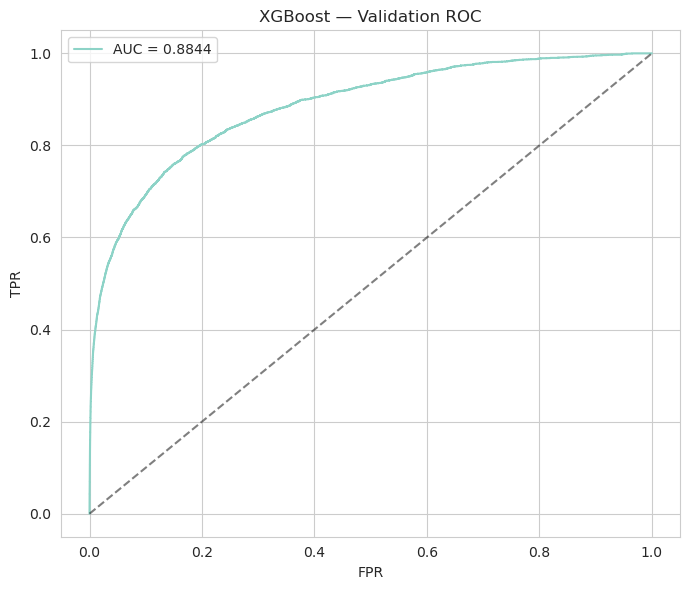

🏃 View run XGBoost_best_on_validation at: https://dagshub.com/ldavi22/cs229-231.mlflow/#/experiments/3/runs/be3a13c4622c450bba9f609263da6e21
🧪 View experiment at: https://dagshub.com/ldavi22/cs229-231.mlflow/#/experiments/3


In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
from scipy.stats import randint, uniform
import mlflow
import dagshub
dagshub.init(repo_owner='ldavi22', repo_name='cs229-231', mlflow=True)
mlflow.set_tracking_uri("https://dagshub.com/ldavi22/cs229-231.mlflow")
mlflow.set_experiment('CIS_Fraud_Detection_XGBOOST_With_150_features')


scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

xgb_param_dist = {
    "n_estimators":     randint(100, 400),
    "learning_rate":    uniform(0.05, 0.15),
    "max_depth":        randint(3, 8),
    "subsample":        uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "gamma":            uniform(0.0, 3.0),
    "reg_alpha":        uniform(0.0, 1.0),
    "reg_lambda":       uniform(0.5, 1.5),
    "min_child_weight": randint(1, 20),
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)
xgb_search.fit(x_train_sel, y_train)

print("\n=== XGBoost best params ===")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV AUC: {xgb_search.best_score_:.4f}")

xgb_best = xgb_search.best_estimator_
xgb_proba = xgb_best.predict_proba(x_valid_sel)[:, 1]
print(f"Validation AUC: {roc_auc_score(y_valid, xgb_proba):.4f}")

fpr, tpr, _ = roc_curve(y_valid, xgb_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("XGBoost — Validation ROC")
plt.legend(); plt.tight_layout()
plt.savefig("xgb_roc.png", dpi=200, bbox_inches="tight")
plt.show()

xgb_results = pd.DataFrame(xgb_search.cv_results_)

for i, row in xgb_results.iterrows():
    with mlflow.start_run(run_name=f"XGBoost_trial_{i:02d}"):
        mlflow.log_param("model", "XGBoost")
        mlflow.log_param("trial", i)
        mlflow.log_param("n_features", x_train_sel.shape[1])
        mlflow.log_param("scoring", "roc_auc")
        mlflow.log_param("scale_pos_weight", scale)
        for k, v in row["params"].items():
            mlflow.log_param(k, v)

        mlflow.log_metric("cv_mean_test_auc",  row["mean_test_score"])
        mlflow.log_metric("cv_std_test_auc",   row["std_test_score"])
        mlflow.log_metric("cv_mean_train_auc", row["mean_train_score"])
        mlflow.log_metric("cv_std_train_auc",  row["std_train_score"])
        mlflow.log_metric("overfit_gap",       row["mean_train_score"] - row["mean_test_score"])
        mlflow.log_metric("rank",              row["rank_test_score"])
        mlflow.log_metric("fit_time_s",        row["mean_fit_time"])
        mlflow.set_tag("is_best", row["rank_test_score"] == 1)

with mlflow.start_run(run_name="XGBoost_best_on_validation"):
    for k, v in xgb_search.best_params_.items():
        mlflow.log_param(f"best_{k}", v)
    xgb_train_proba = xgb_best.predict_proba(x_train_sel)[:, 1]
    xgb_pred = (xgb_proba >= 0.5).astype(int)
    train_auc = roc_auc_score(y_train, xgb_train_proba)
    val_auc = roc_auc_score(y_valid, xgb_proba)
    mlflow.log_metric("cv_best_auc",         xgb_search.best_score_)
    mlflow.log_metric("train_auc",           train_auc)
    mlflow.log_metric("val_auc",             val_auc)
    mlflow.log_metric("overfit_gap",         train_auc - val_auc)
    mlflow.log_metric("val_f1_macro",        f1_score(y_valid, xgb_pred, average="macro"))
    mlflow.log_metric("val_recall_macro",    recall_score(y_valid, xgb_pred, average="macro"))
    mlflow.log_metric("val_precision_macro", precision_score(y_valid, xgb_pred, average="macro"))
    mlflow.log_metric("val_accuracy",        accuracy_score(y_valid, xgb_pred))
    mlflow.log_artifact("xgb_roc.png", artifact_path="plots")

    cm = confusion_matrix(y_valid, xgb_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    mlflow.log_figure(fig, "plots/confusion_matrix.png")
    plt.close(fig)

    mlflow.log_artifact("xgb_roc.png", artifact_path="plots")

    precision, recall, _ = precision_recall_curve(y_valid, xgb_proba)
    ap = average_precision_score(y_valid, xgb_proba)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(recall, precision, label=f"AP = {ap:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("XGBoost — Precision-Recall Curve")
    ax.legend()
    plt.tight_layout()
    mlflow.log_figure(fig, "plots/precision_recall_curve.png")
    plt.close(fig)

    mlflow.log_artifact("xgb_roc.png", artifact_path="plots")

